In [1]:
# 📦 1. 环境准备与数据加载
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 通过 rc 参数设置中文字体（Seaborn 推荐做法）
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif",
        "axes.unicode_minus": False
    }
)

# 加载 flights 数据集：1949-1960 年每月航空客运量
flights = sns.load_dataset("flights")

# 快速查看数据结构
print(flights.head())
print(f"数据规模：{flights.shape}")

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
数据规模：(144, 3)


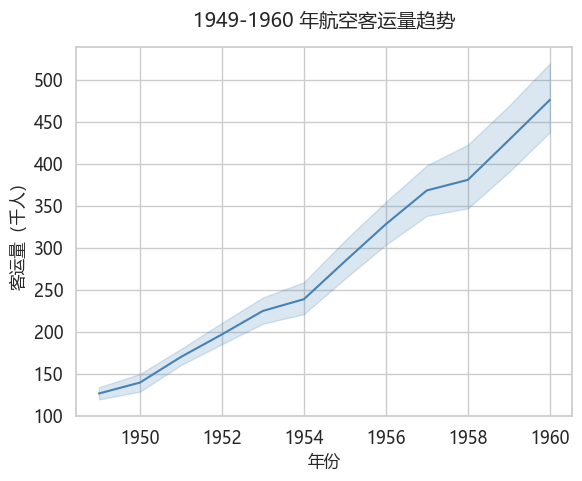

In [2]:
# 📈 2. 基础趋势折线图
# 一行代码！按 year 聚合，画出客运量趋势
sns.lineplot(data=flights, x="year", y="passengers", color="steelblue")

plt.title("1949-1960 年航空客运量趋势", fontsize=14, pad=15)
plt.xlabel("年份", fontsize=12)
plt.ylabel("客运量（千人）", fontsize=12)

plt.show()

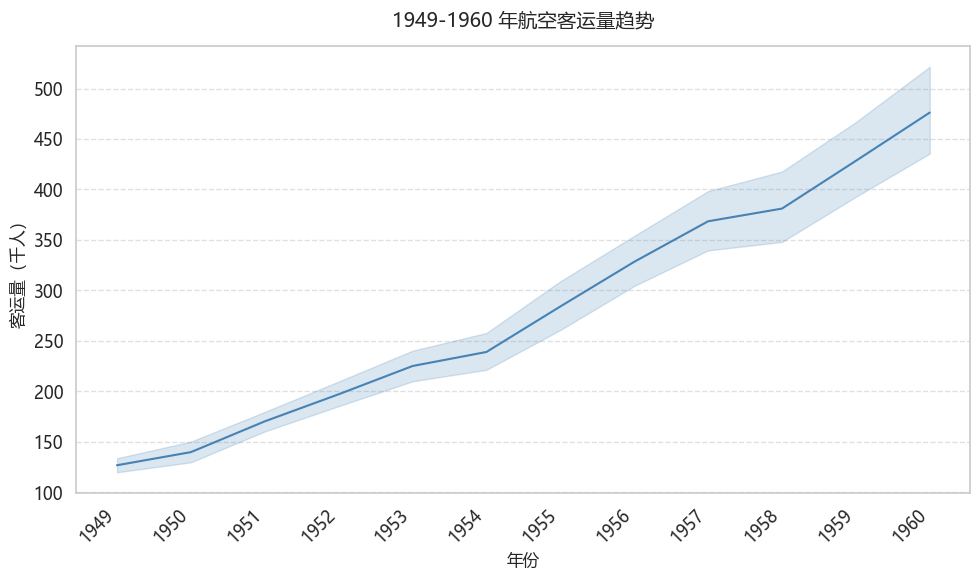

In [3]:
# 📅 3. 进阶：Matplotlib 精细定制
fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn 画主体，绑定到 ax
sns.lineplot(data=flights, x="year", y="passengers", color="steelblue", ax=ax)

# 设置标题和标签
ax.set_title("1949-1960 年航空客运量趋势", fontsize=14, pad=15)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("客运量（千人）", fontsize=12)

# 🔥 核心武器：自定义 x 轴刻度，每年一个刻度
ax.set_xticks(range(1949, 1961, 1))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# 添加水平网格线（仅 y 轴）
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

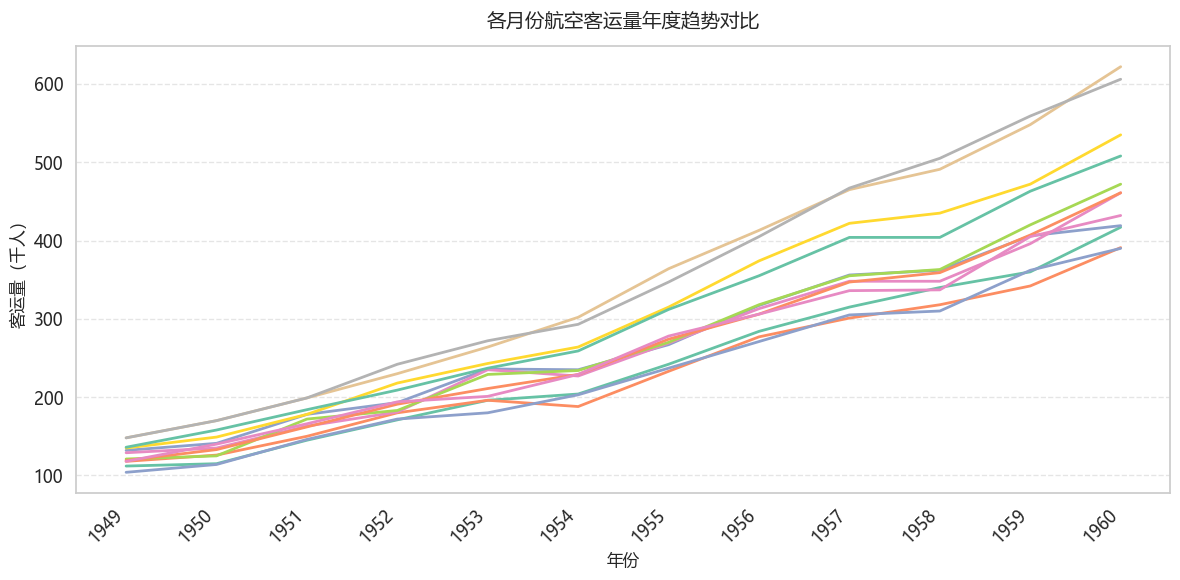

In [4]:
# 🚀 4. 高级玩法：按月份分组，揭示季节性
fig, ax = plt.subplots(figsize=(12, 6))

# hue="month" 按月份分组，12 条线 = 12 个月份的年度趋势
sns.lineplot(data=flights, x="year", y="passengers", hue="month",
             palette="Set2", linewidth=2, ax=ax, legend=False)

ax.set_title("各月份航空客运量年度趋势对比", fontsize=14, pad=15)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("客运量（千人）", fontsize=12)

# x 轴刻度
ax.set_xticks(range(1949, 1961, 1))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# 网格线
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

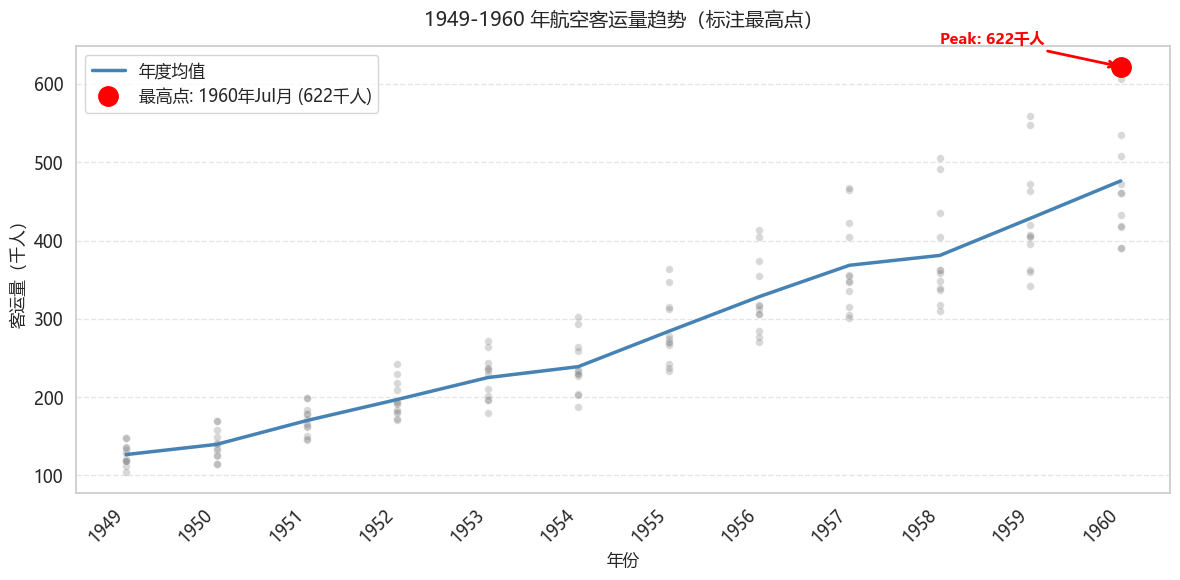

In [5]:
# 🏆 5. 标注历史最高点
fig, ax = plt.subplots(figsize=(12, 6))

# 先画总趋势（按年份聚合的均值）
sns.lineplot(data=flights, x="year", y="passengers",
             color="steelblue", linewidth=2.5, ax=ax,
             errorbar=None, label="年度均值")

# 找到客运量最高的记录
peak_idx = flights["passengers"].idxmax()
peak_row = flights.loc[peak_idx]
peak_year = peak_row["year"]
peak_month = peak_row["month"]
peak_value = peak_row["passengers"]

# 在原始数据上叠加所有月度散点
sns.scatterplot(data=flights, x="year", y="passengers",
                color="gray", alpha=0.3, s=30, ax=ax)

# 高亮最高点：红色大圆点
ax.plot(peak_year, peak_value, "o", color="red", markersize=14, zorder=5,
        label=f"最高点: {peak_year}年{peak_month}月 ({peak_value}千人)")

# 添加注释文字
ax.annotate(f"Peak: {peak_value}千人",
            xy=(peak_year, peak_value),
            xytext=(peak_year - 2, peak_value + 30),
            fontsize=11, fontweight="bold", color="red",
            arrowprops=dict(arrowstyle="->", color="red", lw=2))

ax.set_title("1949-1960 年航空客运量趋势（标注最高点）", fontsize=14, pad=15)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("客运量（千人）", fontsize=12)

ax.set_xticks(range(1949, 1961, 1))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend(loc="upper left")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

✅ 图表已保存为 'trend_lineplot.png'


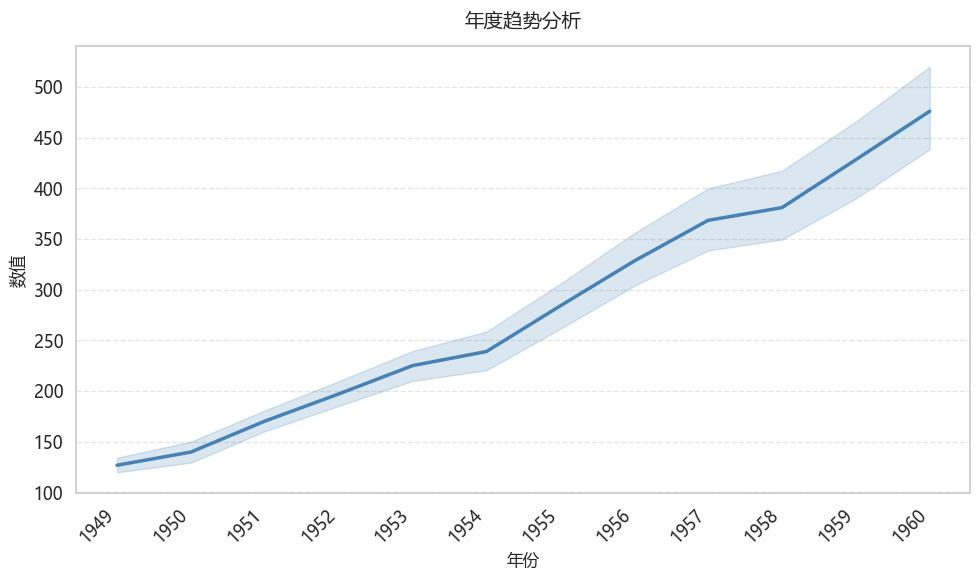

In [6]:
# 💾 6. 完整代码模板（含高清导出）
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 设置主题 + 中文支持
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif",
        "axes.unicode_minus": False
    }
)

# 2. 加载数据（可替换为你自己的 CSV）
# df = pd.read_csv("your_data.csv", parse_dates=["date"])
flights = sns.load_dataset("flights")

# 3. 创建画布
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Seaborn 画折线图
sns.lineplot(data=flights, x="year", y="passengers",
             color="steelblue", linewidth=2.5, ax=ax)

# 5. 标题和标签
ax.set_title("年度趋势分析", fontsize=14, pad=15)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("数值", fontsize=12)

# 6. Matplotlib 自定义刻度
ax.set_xticks(range(1949, 1961, 1))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# 7. 网格线
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)

plt.tight_layout()

# 8. 导出与显示
fig.savefig("trend_lineplot.png", dpi=300, bbox_inches="tight")
print("✅ 图表已保存为 'trend_lineplot.png'")
plt.show()